# ETTh1 残差/非残差分解可视化

本笔记使用项目内的移动平均分解逻辑（`utils.tools.moving_average_decompose`）对 ETTh1 数据集的 `OT` 序列进行分解，并绘制原始、残差、非残差序列。

In [4]:
import os
import sys
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import configparser
from types import SimpleNamespace

%matplotlib inline

# 项目根目录，确保能导入 utils 和 data_provider
PROJ_ROOT = Path.cwd().resolve().parent
if str(PROJ_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJ_ROOT))

from utils.tools import moving_average_decompose
from data_provider.data_factory import data_provider

plt.style.use('seaborn-v0_8-darkgrid')

# 配置
conf_path = PROJ_ROOT / 'data_configs' / 'ETTh1.conf'
target_col = 'OT'
seq_len = 96
trend_kernel = 16  # 与训练时的 trend_kernel 保持一致


In [5]:
# 通过项目的数据加载器读取一批数据，并截取一个窗口
assert conf_path.exists(), f"Missing config: {conf_path}"
config = configparser.ConfigParser()
config.read(conf_path)
cfg = config['config']

# 绝对路径，避免相对路径受 notebook 工作目录影响
abs_data_path = (PROJ_ROOT / cfg['data_path']).resolve()
assert abs_data_path.exists(), f"Missing data path: {abs_data_path}"

# 构造与 data_provider 兼容的最小参数集合
args = SimpleNamespace(
    data_path=str(abs_data_path),
    data_reader=cfg['data_reader'],
    data_id=cfg['data_id'],
    features=cfg['features'],
    seq_len=int(cfg['seq_len']),
    label_len=int(cfg.get('label_len', 0)),
    pred_len=seq_len,  # 与当前分析窗口保持一致
    stride=int(cfg['stride']),
    batch_size=int(cfg['batch_size']),
    percent=100,
    target=target_col,
    mask_rate=-1,
    num_workers=0,
    logger=SimpleNamespace(info=lambda *a, **k: None),
)

_, loader = data_provider(args, 'train')
batch_x, batch_y = next(iter(loader))
# 取第一条样本的前 seq_len 点作为演示窗口
window = batch_x[0, :seq_len, :1].numpy().squeeze()  # (seq_len,)

# 移动平均分解
tensor_window = torch.from_numpy(window).unsqueeze(0).unsqueeze(-1)  # [1, T, 1]
trend_series, residual_series = moving_average_decompose(tensor_window, trend_kernel)
trend_series = trend_series.squeeze().numpy()
residual_series = residual_series.squeeze().numpy()
non_residual = trend_series  # 这里的非残差等同于趋势（无季节项）
recon = non_residual + residual_series

print('window shape:', window.shape)
print('trend shape:', trend_series.shape)
print('residual shape:', residual_series.shape)
print('max recon error:', np.max(np.abs(window - recon)))

window shape: (96,)
trend shape: (96,)
residual shape: (96,)
max recon error: 5.551115123125783e-17


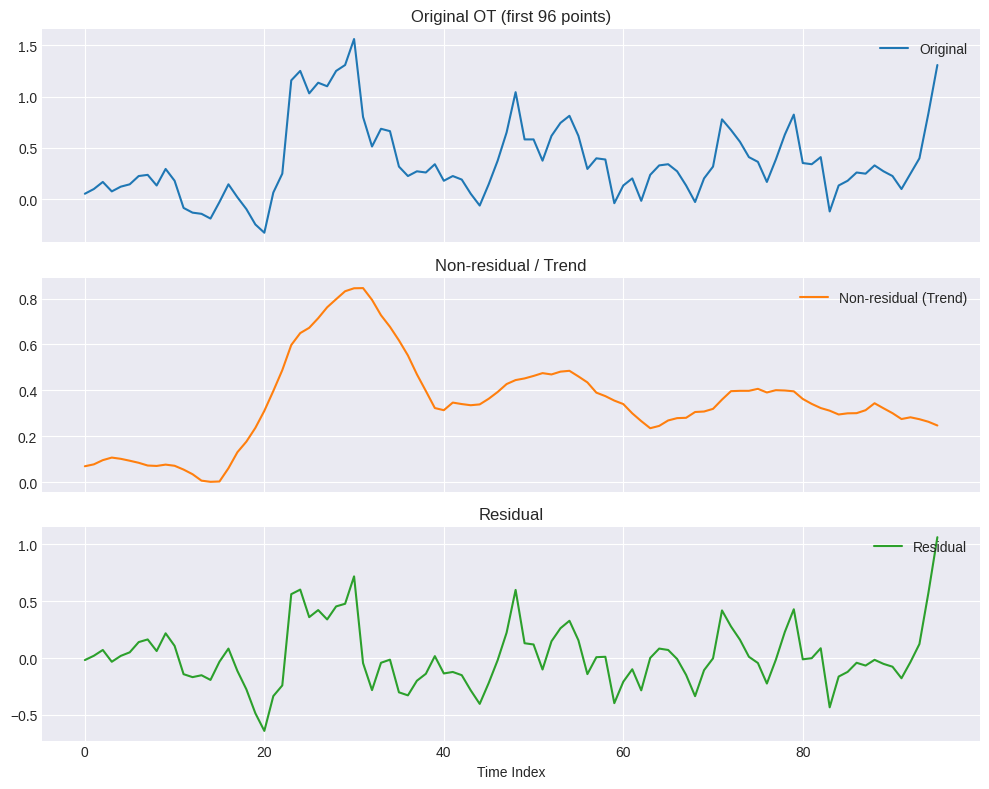

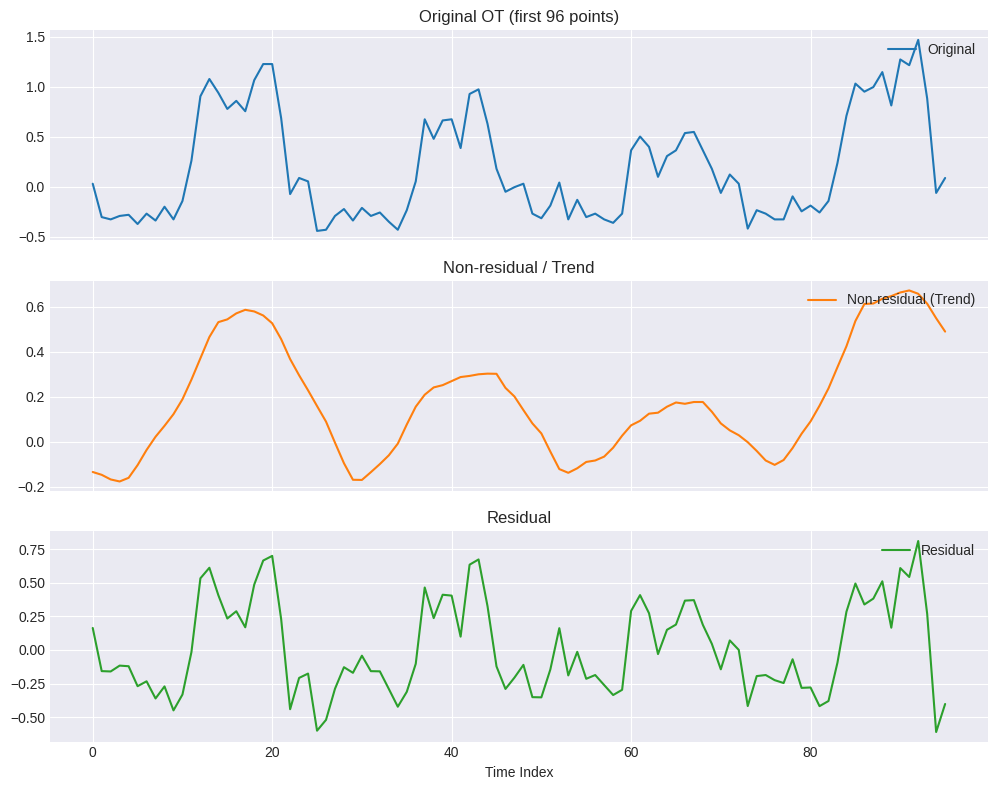

In [6]:
# 可视化原始、趋势（非残差）、残差
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(window, label='Original', color='C0')
axes[0].legend(loc='upper right')
axes[0].set_title('Original OT (first {} points)'.format(seq_len))

axes[1].plot(non_residual, label='Non-residual (Trend)', color='C1')
axes[1].legend(loc='upper right')
axes[1].set_title('Non-residual / Trend')

axes[2].plot(residual_series, label='Residual', color='C2')
axes[2].legend(loc='upper right')
axes[2].set_title('Residual')

axes[-1].set_xlabel('Time Index')
plt.tight_layout()
plt.show()

In [7]:
# 验证残差 + 非残差是否复原原始序列
recon = non_residual + residual_series
max_err = np.max(np.abs(window - recon))
print('max reconstruction error:', max_err)
assert np.allclose(window, recon, atol=1e-8), 'Reconstruction mismatch exceeds tolerance'
print('Reconstruction check passed (allclose within 1e-8).')

max reconstruction error: 5.551115123125783e-17
Reconstruction check passed (allclose within 1e-8).


## 简单演示：分解后分别走非残差/残差分支（占位示例）
下方单元不加载大模型，仅用分解后的序列分别代表本地分支（非残差）与全局分支（残差）输出，验证组合流程。

In [8]:
# 占位示例：非残差/残差分别走各自分支后再合成
# 这里用恒等映射代替真实模型，演示管线
local_output = non_residual            # 本地非残差分支输出（趋势）
global_output = residual_series        # 全局残差分支输出
combined = local_output + global_output

mse = np.mean((window - combined) ** 2)
print('Combined output MSE vs original:', mse)


Combined output MSE vs original: 1.0865486116100678e-34
